<h2 style='color:blue' align="center">Logistic Regression: Multiclass Classification</h2>

In this tutorial we will see how to use logistic regression for multiclass classification.

In [1]:
from sklearn.datasets import load_digits
%matplotlib inline
import matplotlib.pyplot as plt
digits = load_digits()

<Figure size 640x480 with 0 Axes>

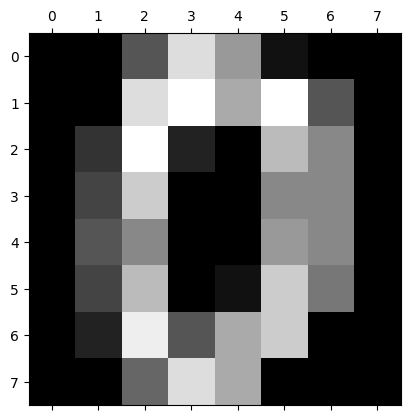

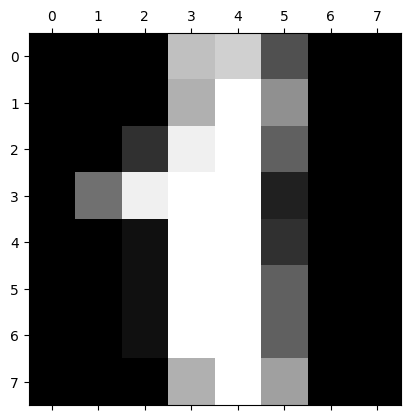

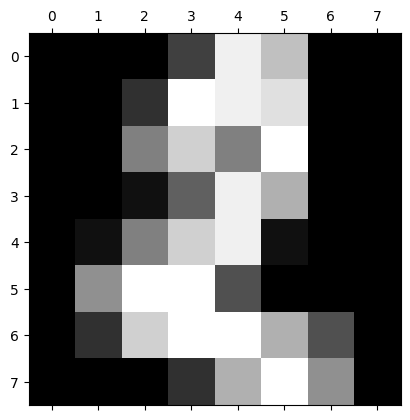

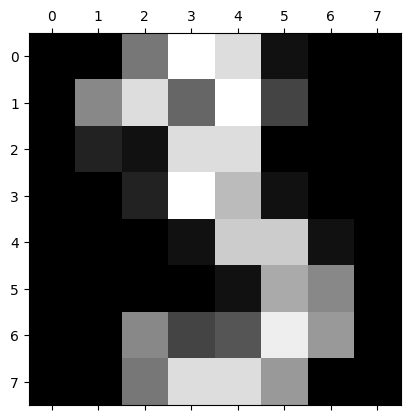

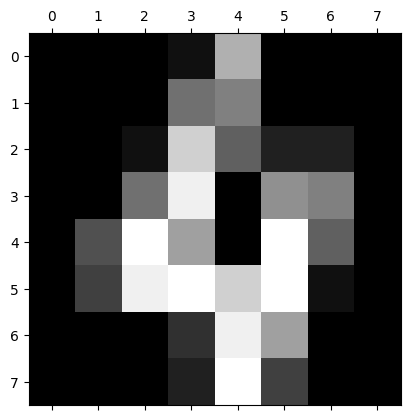

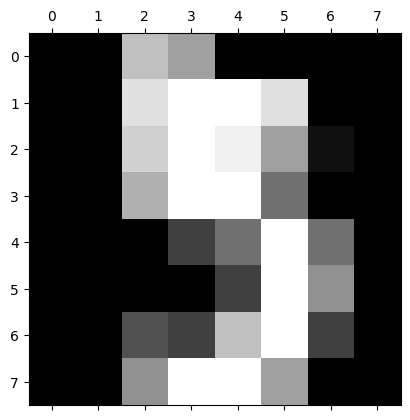

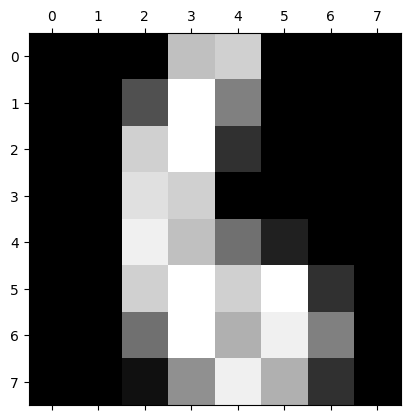

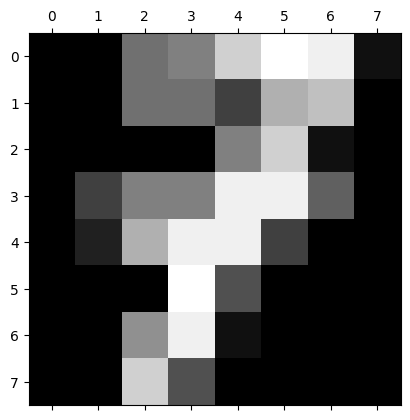

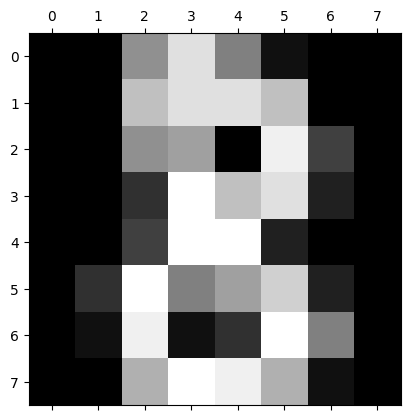

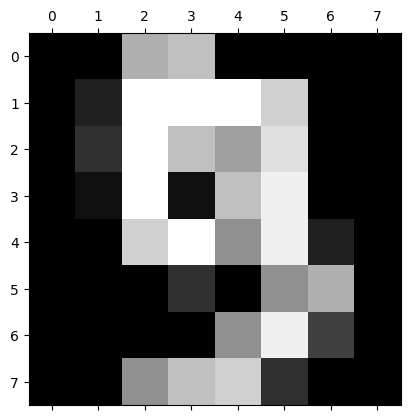

In [2]:
plt.gray()
for i in range(10):
    plt.matshow(digits.images[i])

In [3]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [6]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

<h4 style='color:purple'>Create and train logistic regression model</h4>

In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(digits.data,digits.target, test_size=0.2)

In [10]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

<h4 style='color:purple'>Measure accuracy of our model</h4>

In [11]:
model.score(X_test, y_test)

0.9694444444444444

In [12]:
model.predict(digits.data[0:5])

array([0, 1, 2, 3, 4])

<h4 style='color:purple'>Confusion Matrix</h4>

In [13]:
y_predicted = model.predict(X_test)

Evaluation

In [17]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #importing all the metrics

In [18]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_predicted))

# Detailed report
print(classification_report(y_test, y_predicted))

Accuracy: 0.9694444444444444
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.94      0.97      0.96        34
           2       0.97      0.97      0.97        38
           3       1.00      0.89      0.94        46
           4       1.00      0.94      0.97        35
           5       0.94      0.97      0.96        33
           6       1.00      1.00      1.00        37
           7       0.97      1.00      0.99        34
           8       0.94      0.97      0.96        33
           9       0.93      1.00      0.97        42

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[28,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 33,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  1, 37,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1, 41,  0,  2,  0,  0,  1,  1],
       [ 0,  1,  0,  0, 33,  0,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0, 32,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 37,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 34,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 32,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 42]])

Text(95.72222222222221, 0.5, 'Truth')

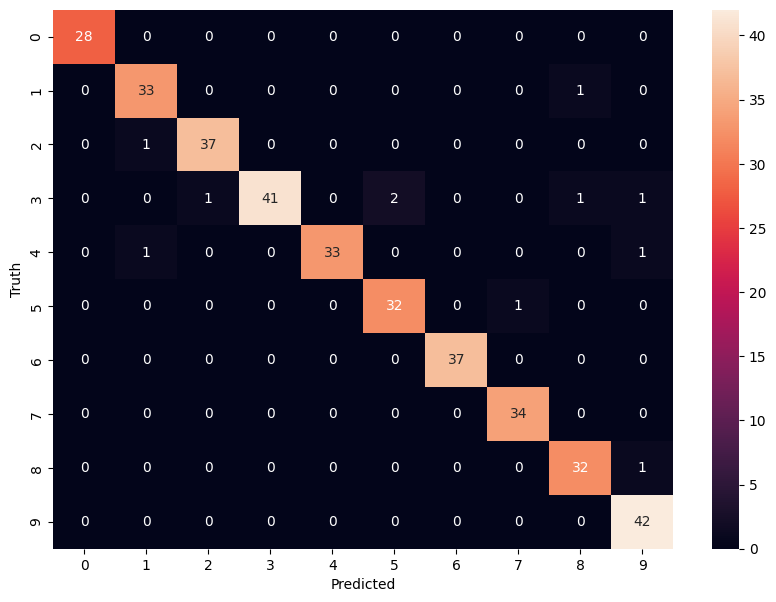

In [15]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

With Irish Data

We will start with importing libraries as usual because of remebering the code

In [20]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import dataset loader from sklearn
from sklearn.datasets import load_digits

# Import tools for splitting dataset
from sklearn.model_selection import train_test_split

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load the dataset

In [22]:
# Load the dataset

df = pd.read_csv("/content/Iris.csv")

# Display dataset information
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [24]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Understand the shape

In [25]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Check column names
print("Columns:", df.columns)

# Basic information about dataset
df.info()

Dataset Shape: (150, 6)
Columns: Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Check Target Classes

In [26]:
# Check unique species in dataset
print(df['Species'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


Convert Categorical Labels to Numbers

import label encoder function

In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
# Convert species names into numeric labels

encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])

# Check encoded labels
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


Define Features and Target

In [30]:
# Drop the Id column (not useful for prediction)

X = df.drop(['Id','Species'], axis=1)

# Target variable
y = df['Species']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


We split the dataset:

80% training data

20% testing data

Training data → teach the model
Testing data → evaluate performance

In [55]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (90, 4)
Testing samples: (60, 4)


Model Training

In [56]:
# Create Logistic Regression model

model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

LogisticRegression()

Model Evaluation

In [57]:
# Predict species for test data

y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred[:10])

Predicted values:
[1 0 2 1 1 0 1 2 1 1]


In [58]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [59]:
# Detailed report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        18

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [60]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[23  0  0]
 [ 0 19  0]
 [ 0  0 18]]


Predicting a new sample

In [37]:
# Example flower measurement
# [SepalLength, SepalWidth, PetalLength, PetalWidth]

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted class:", prediction)

print("Predicted species:", encoder.inverse_transform(prediction))

Predicted class: [0]
Predicted species: ['Iris-setosa']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Scatter plot to understand the data

In [51]:
# Import required libraries
import seaborn as sns

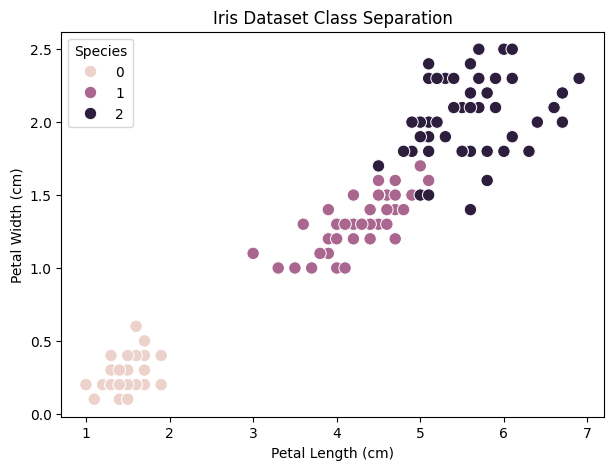

In [52]:
# Scatter plot to visualize class separation

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species',
    data=df,
    s=80
)

plt.title("Iris Dataset Class Separation")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

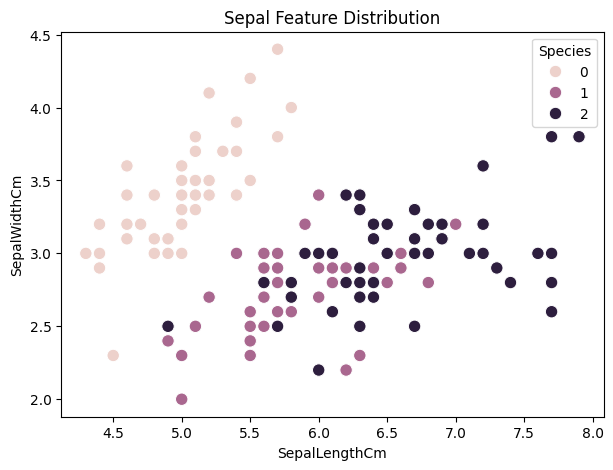

In [53]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='SepalLengthCm',
    y='SepalWidthCm',
    hue='Species',
    data=df,
    s=80
)

plt.title("Sepal Feature Distribution")

plt.show()

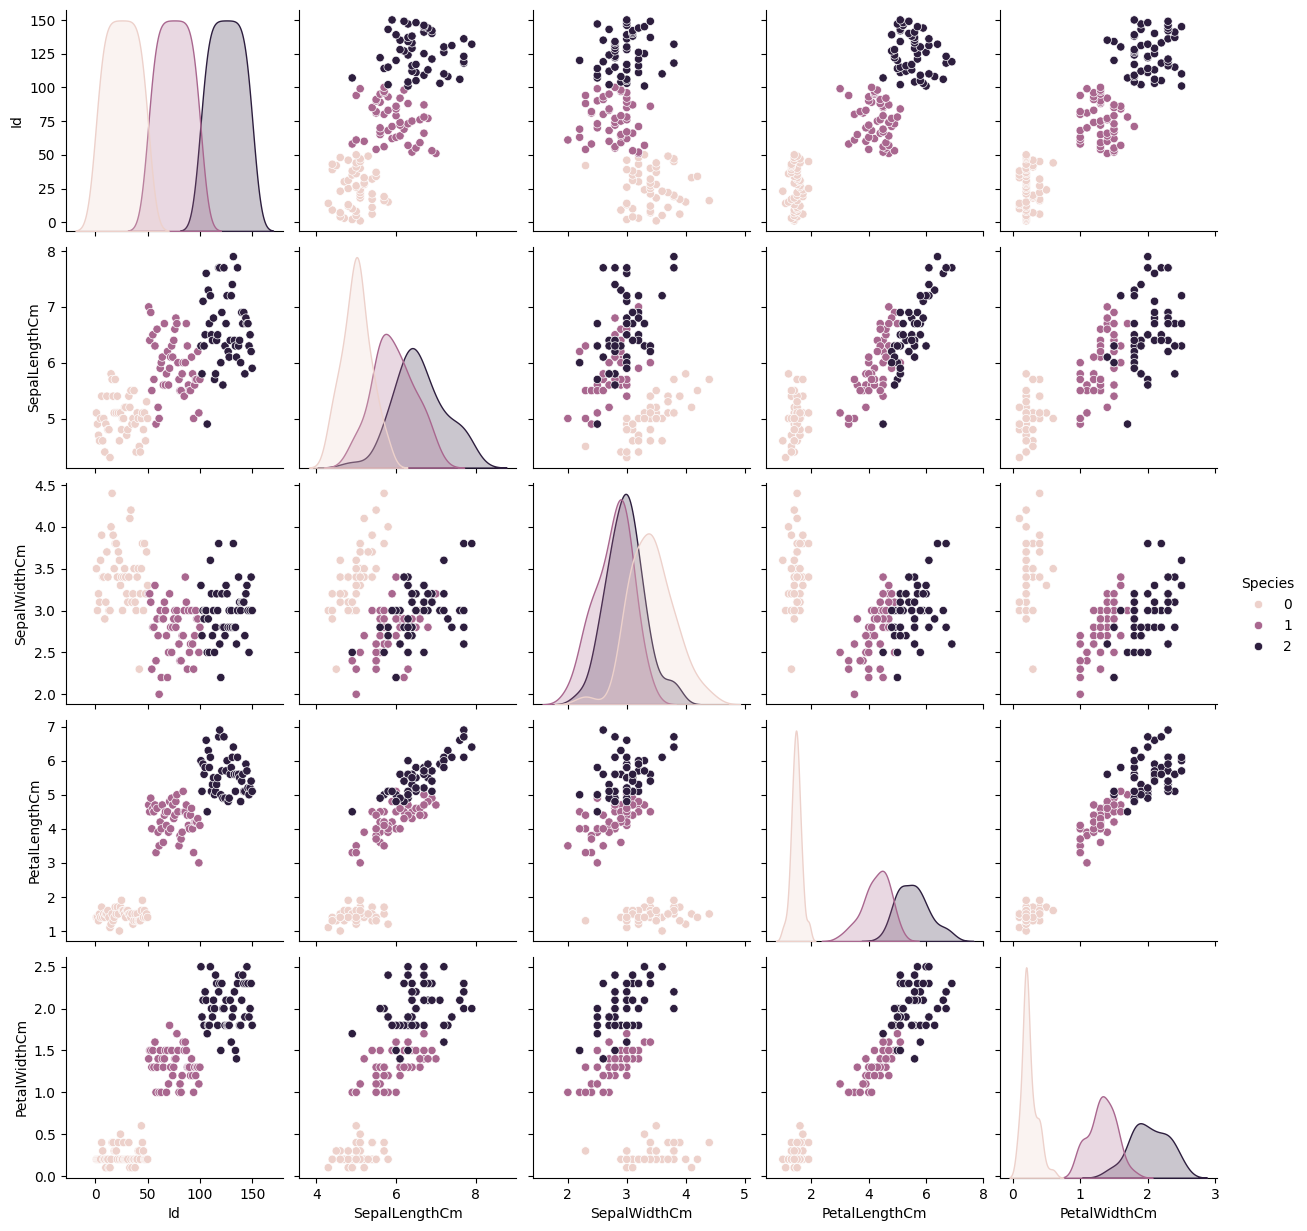

In [54]:
# Pairplot for all features

sns.pairplot(df, hue="Species")

plt.show()